<a href="https://colab.research.google.com/github/binamira/Detecting_Docker_Container_Escape_Attacks/blob/main/Detecting_Docker_Container_Escape_Attacks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecting Docker Container Escape Attacks Through System Call Sequence Analysis and Linux Capability Profiling: A Comparative Machine Learning and Deep Learning Study







## Cell 01 — Install and Import Required Libraries

In [ ]:
# =========================
# Cell 01 — Install and Import Required Libraries
# =========================



import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import sparse

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    print("XGBoost is not available. HistGradientBoostingClassifier will be used as fallback.")
    print("Reason:", e)
    XGBOOST_AVAILABLE = False

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Embedding, Conv1D, GlobalMaxPooling1D
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.regularizers import l2
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    tf.random.set_seed(RANDOM_STATE)
    TENSORFLOW_AVAILABLE = True
except Exception as e:
    print("TensorFlow is not available. Deep learning cells will explain how to install it.")
    print("Reason:", e)
    TENSORFLOW_AVAILABLE = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

print("Imports complete.")


Imports complete.


## Cell 02 — Upload CSV in Google Colab

In [ ]:
# =========================
# Cell 02 — Upload CSV in Google Colab
# =========================



try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    uploaded = files.upload()
    print("Uploaded files:", list(uploaded.keys()))
else:
    print("Not running in Google Colab. Skipping manual upload.")


Saving docker-container-attack.csv to docker-container-attack.csv
Uploaded files: ['docker-container-attack.csv']


## Cell 03 — Load Dataset

In [ ]:
# =========================
# Cell 03 — Load Dataset
# =========================

COLAB_CSV_PATH = Path("/content/docker-container-attack.csv")

LOCAL_CANDIDATES = [
    Path("docker-container-attack.csv"),
    Path("data/raw/docker-container-attack.csv"),
    Path("../data/raw/docker-container-attack.csv"),
    Path("../../data/raw/docker-container-attack.csv")
]

def find_dataset_path():
    candidates = []

    if COLAB_CSV_PATH.exists():
        candidates.append(COLAB_CSV_PATH)

    candidates.extend(LOCAL_CANDIDATES)

    for p in candidates:
        if p.exists():
            return p

    for p in Path.cwd().rglob("*.csv"):
        if "docker" in p.name.lower() or "attack" in p.name.lower() or "container" in p.name.lower():
            return p

    raise FileNotFoundError(
        "Could not find the CSV file. "
        "In Colab, run Cell 02 and upload docker-container-attack.csv. "
        "Locally, place the file at data/raw/docker-container-attack.csv."
    )

DATA_PATH = find_dataset_path()
df_raw = pd.read_csv(DATA_PATH)

print("Loaded dataset from:", DATA_PATH)
print("Dataset shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.dtypes.to_frame("dtype"))


Loaded dataset from: /content/docker-container-attack.csv
Dataset shape: (61297, 6)


,ContainerName,AddedCapabilitiesList,DroppedCapabilitiesList,SystemCallsList,ReturnValueList,IsSafe
0,mount_attack_container,[SYS_ADMIN SETGID SETUID CHOWN FOWNER DAC_OVER...,[ALL],61 13 16 14 61 15 0 262 262 262 262 262 262 10...,7 0 0 0 -1 0 833 0 -1 -1 -1 0 0 0 0 0 0 0 0 0 ...,False
1,override,[DAC_OVERRIDE DAC_READ_SEARCH CHOWN SETGID SET...,[ALL],61 13 16 14 61 15 0 262 262 262 262 262 262 10...,7 0 0 0 -1 0 338 0 -1 -1 -1 0 0 0 0 0 0 0 0 0 ...,False
2,process_injection_container,[SYS_PTRACE SETGID SETUID CHOWN FOWNER DAC_OVE...,[ALL],61 13 16 14 61 15 0 5 1 14 14 8 56 14 14 14 14...,5044 0 0 0 -1 0 357 0 5 0 0 282 5107 0 0 0 0 0...,False
3,reverse-shell,[SYS_MODULE],[ALL],61 13 16 16 102 107 104 108 102 107 104 108 26...,7 0 0 0 0 0 0 0 0 0 0 0 -1 0 0 0 -1 0 3 0 3772...,False
4,socket_escape_container,[SETGID SETUID CHOWN FOWNER DAC_OVERRIDE],[ALL],61 13 16 14 61 15 0 262 262 262 262 262 262 10...,7 0 0 0 -1 0 120 0 -1 -1 -1 0 0 0 0 0 0 0 0 0 ...,False


,dtype
ContainerName,object
AddedCapabilitiesList,object
DroppedCapabilitiesList,object
SystemCallsList,object
ReturnValueList,object
IsSafe,bool


## Cell 04 — Basic Dataset Inspection

In [ ]:
# =========================
# Cell 04 — Basic Dataset Inspection
# =========================

df = df_raw.copy()

print("Shape:", df.shape)
print("\nColumns:")
for i, col in enumerate(df.columns):
    print(f"{i:02d}. {col}")

print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

display(df.describe(include="all").T.head(30))


Shape: (61297, 6)

Columns:
00. ContainerName
01. AddedCapabilitiesList
02. DroppedCapabilitiesList
03. SystemCallsList
04. ReturnValueList
05. IsSafe

Missing values per column:


,missing_count
SystemCallsList,12
ReturnValueList,8
DroppedCapabilitiesList,2
AddedCapabilitiesList,1
ContainerName,0
IsSafe,0



Duplicate rows: 13155


,count,unique,top,freq
ContainerName,61297,6,safe-container,31232
AddedCapabilitiesList,61296,14,[SYS_MODULE],9124
DroppedCapabilitiesList,61295,10,[ALL],33151
SystemCallsList,61285,2876,61 13 16 14 61 15 0 262 262 262 262 262 262 10...,4270
ReturnValueList,61289,29375,7 0 0 0 -1 0 115 0 -1 -1 -1 0 0 0 0 0 0 0 0 0 ...,563
IsSafe,61297,2,True,31232


## Cell 05 — Remove Duplicates and Normalize Column Names Internally

In [ ]:
# =========================
# Cell 05 — Remove Duplicates and Normalize Column Names Internally
# =========================

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)

col_lookup = {col.lower().strip(): col for col in df.columns}

def find_columns_by_keywords(keywords):
    matched = []
    for col in df.columns:
        low = col.lower()
        if any(k.lower() in low for k in keywords):
            matched.append(col)
    return matched

print("Duplicate removal complete.")


Shape after duplicate removal: (48142, 6)
Duplicate removal complete.


## Cell 06 — Construct Binary Target Label

In [ ]:
# =========================
# Cell 06 — Construct Binary Target Label
# =========================

def construct_binary_label(df):
    """
    Creates y where:
    0 = safe / benign
    1 = unsafe / container escape attack
    """
    columns_lower = {c.lower().strip(): c for c in df.columns}

    for key in ["issafe", "is_safe", "safe"]:
        if key in columns_lower:
            col = columns_lower[key]
            s = df[col]

            if s.dtype == bool:
                y = (~s).astype(int)
            else:
                s_str = s.astype(str).str.lower().str.strip()
                safe_values = {"true", "1", "yes", "safe", "benign", "normal"}
                y = (~s_str.isin(safe_values)).astype(int)

            print(f"Target constructed from column: {col}")
            print("Mapping: safe/benign = 0, unsafe/attack = 1")
            return y, col

    candidate_label_cols = find_columns_by_keywords(["label", "class", "target", "attack", "status"])
    for col in candidate_label_cols:
        s = df[col].astype(str).str.lower().str.strip()
        unique_vals = set(s.dropna().unique())

        if any(v in unique_vals for v in ["safe", "benign", "normal"]) and any(
            v in unique_vals for v in ["unsafe", "attack", "malicious", "escape"]
        ):
            y = s.apply(lambda x: 0 if x in ["safe", "benign", "normal"] else 1).astype(int)
            print(f"Target constructed from column: {col}")
            print("Mapping: safe/benign/normal = 0, unsafe/attack/malicious = 1")
            return y, col

    raise ValueError(
        "Could not automatically construct the target label. "
        "Please inspect the dataset columns and manually define y."
    )

y, TARGET_SOURCE_COLUMN = construct_binary_label(df)

print("\nClass distribution:")
display(y.value_counts().rename(index={0: "safe/benign", 1: "unsafe/attack"}).to_frame("count"))

print("\nClass ratio:")
display((y.value_counts(normalize=True) * 100).rename(index={0: "safe/benign", 1: "unsafe/attack"}).to_frame("percentage"))


Target constructed from column: IsSafe
Mapping: safe/benign = 0, unsafe/attack = 1

Class distribution:


,count
IsSafe,
safe/benign,29438
unsafe/attack,18704



Class ratio:


,percentage
IsSafe,
safe/benign,61.14827
unsafe/attack,38.85173


## Cell 07 — Identify Syscall, Capability, Return, and Group Columns

In [ ]:
# =========================
# Cell 07 — Identify Syscall, Capability, Return, and Group Columns
# =========================

SYSCALL_COLUMNS = find_columns_by_keywords(["syscall", "system call", "trace", "calls", "sequence"])

CAPABILITY_COLUMNS = find_columns_by_keywords(["capability", "capabilities", "cap_", "added", "dropped"])

RETURN_COLUMNS = find_columns_by_keywords(["return", "retval", "ret", "exit", "status"])

POTENTIAL_GROUP_COLUMNS = find_columns_by_keywords([
    "file", "filename", "scenario", "container", "container_id", "trace_id",
    "sample", "program", "image", "attack_name", "experiment"
])

SYSCALL_COLUMNS = [c for c in SYSCALL_COLUMNS if c != TARGET_SOURCE_COLUMN]
CAPABILITY_COLUMNS = [c for c in CAPABILITY_COLUMNS if c != TARGET_SOURCE_COLUMN]
RETURN_COLUMNS = [c for c in RETURN_COLUMNS if c != TARGET_SOURCE_COLUMN]
POTENTIAL_GROUP_COLUMNS = [c for c in POTENTIAL_GROUP_COLUMNS if c != TARGET_SOURCE_COLUMN]

print("Detected syscall columns:", SYSCALL_COLUMNS)
print("Detected capability columns:", CAPABILITY_COLUMNS)
print("Detected return/status columns:", RETURN_COLUMNS)
print("Potential group columns:", POTENTIAL_GROUP_COLUMNS)

if not SYSCALL_COLUMNS:
    print("\nWARNING: No syscall columns detected automatically.")
    print("Inspect the columns above and manually set SYSCALL_COLUMNS.")


Detected syscall columns: ['SystemCallsList']
Detected capability columns: ['AddedCapabilitiesList', 'DroppedCapabilitiesList']
Detected return/status columns: ['ReturnValueList']
Potential group columns: ['ContainerName']


## Cell 08 — Text Parsing and Feature Helper Functions

In [ ]:
# =========================
# Cell 08 — Text Parsing and Feature Helper Functions
# =========================

def combine_text_columns(df, cols):
    if not cols:
        return pd.Series([""] * len(df), index=df.index)

    combined = df[cols].fillna("").astype(str).agg(" ".join, axis=1)
    return combined

def normalize_trace_text(text):
    text = str(text).lower()
    text = re.sub(r"[\[\]\(\)\{\},;:|/\\=]", " ", text)
    text = re.sub(r"[^a-zA-Z0-9_+\-. ]+", " ", text)
    tokens = re.findall(r"[a-zA-Z_][a-zA-Z0-9_+\-.]*", text)
    return " ".join(tokens)

def tokenize_text(text):
    cleaned = normalize_trace_text(text)
    if not cleaned.strip():
        return []
    return cleaned.split()

def numeric_values_from_text(text):
    values = re.findall(r"-?\d+\.?\d*", str(text))
    try:
        return [float(v) for v in values]
    except Exception:
        return []

def safe_divide(a, b):
    return a / b if b not in [0, 0.0, None] else 0.0


## Cell 09 — Feature Engineering

In [ ]:
# =========================
# Cell 09 — Feature Engineering
# =========================

feature_df = pd.DataFrame(index=df.index)

raw_syscall_text = combine_text_columns(df, SYSCALL_COLUMNS)
feature_df["syscall_text"] = raw_syscall_text.apply(normalize_trace_text)

raw_capability_text = combine_text_columns(df, CAPABILITY_COLUMNS)
feature_df["capability_text"] = raw_capability_text.apply(normalize_trace_text)

sys_tokens = feature_df["syscall_text"].apply(tokenize_text)

feature_df["syscall_token_count"] = sys_tokens.apply(len)
feature_df["syscall_unique_count"] = sys_tokens.apply(lambda x: len(set(x)))
feature_df["syscall_unique_ratio"] = [
    safe_divide(u, n) for u, n in zip(feature_df["syscall_unique_count"], feature_df["syscall_token_count"])
]

cap_tokens = feature_df["capability_text"].apply(tokenize_text)

feature_df["capability_token_count"] = cap_tokens.apply(len)
feature_df["capability_unique_count"] = cap_tokens.apply(lambda x: len(set(x)))
feature_df["capability_unique_ratio"] = [
    safe_divide(u, n) for u, n in zip(feature_df["capability_unique_count"], feature_df["capability_token_count"])
]

HIGH_RISK_CAPS = [
    "cap_sys_admin", "sys_admin",
    "cap_sys_module", "sys_module",
    "cap_sys_ptrace", "sys_ptrace",
    "cap_sys_chroot", "sys_chroot",
    "cap_dac_override", "dac_override",
    "cap_net_admin", "net_admin",
    "cap_sys_boot", "sys_boot",
    "cap_mknod", "mknod"
]

risk_indicator_cols = []
for cap in HIGH_RISK_CAPS:
    clean_name = cap.replace("cap_", "")
    col_name = f"has_{clean_name}"
    feature_df[col_name] = feature_df["capability_text"].str.contains(cap, regex=False).astype(int)
    risk_indicator_cols.append(col_name)

feature_df["high_risk_capability_hits"] = feature_df[risk_indicator_cols].sum(axis=1)

raw_return_text = combine_text_columns(df, RETURN_COLUMNS)
return_values = raw_return_text.apply(numeric_values_from_text)

feature_df["return_count"] = return_values.apply(len)
feature_df["return_mean"] = return_values.apply(lambda x: np.mean(x) if len(x) else 0.0)
feature_df["return_std"] = return_values.apply(lambda x: np.std(x) if len(x) else 0.0)
feature_df["return_min"] = return_values.apply(lambda x: np.min(x) if len(x) else 0.0)
feature_df["return_max"] = return_values.apply(lambda x: np.max(x) if len(x) else 0.0)
feature_df["return_negative_ratio"] = return_values.apply(
    lambda x: safe_divide(sum(v < 0 for v in x), len(x)) if len(x) else 0.0
)

print("Engineered feature dataframe shape:", feature_df.shape)
display(feature_df.head())


Engineered feature dataframe shape: (48142, 23)


,syscall_text,capability_text,syscall_token_count,syscall_unique_count,syscall_unique_ratio,capability_token_count,capability_unique_count,capability_unique_ratio,has_sys_admin,has_sys_module,has_sys_ptrace,has_sys_chroot,has_dac_override,has_net_admin,has_sys_boot,has_mknod,high_risk_capability_hits,return_count,return_mean,return_std,return_min,return_max,return_negative_ratio
0,,sys_admin setgid setuid chown fowner dac_overr...,0,0,0.0,7,7,1.0,1,0,0,0,1,0,0,0,4,171,25.853801,131.951377,-1.0,833.0,0.105263
1,,dac_override dac_read_search chown setgid setu...,0,0,0.0,7,7,1.0,0,0,0,0,1,0,0,0,2,297,15.326599,54.759078,-1.0,338.0,0.104377
2,,sys_ptrace setgid setuid chown fowner dac_over...,0,0,0.0,7,7,1.0,0,0,1,0,1,0,0,0,4,120,404.558333,1340.966690,-1.0,5114.0,0.091667
3,,sys_module all,0,0,0.0,2,2,1.0,0,1,0,0,0,0,0,0,2,314,46.280255,469.700946,-1.0,7415.0,0.060510
4,,setgid setuid chown fowner dac_override all,0,0,0.0,6,6,1.0,0,0,0,0,1,0,0,0,2,92,6.684783,25.387831,-1.0,139.0,0.108696


## Cell 10 — Shortcut and Leakage Diagnostic

Group means by target class:


target_attack,0,1
syscall_token_count,0.000000,0.000000
syscall_unique_count,0.000000,0.000000
capability_token_count,2.000000,5.215088
capability_unique_count,1.900435,5.215088
high_risk_capability_hits,1.521843,2.838858
return_count,100.187818,175.866018


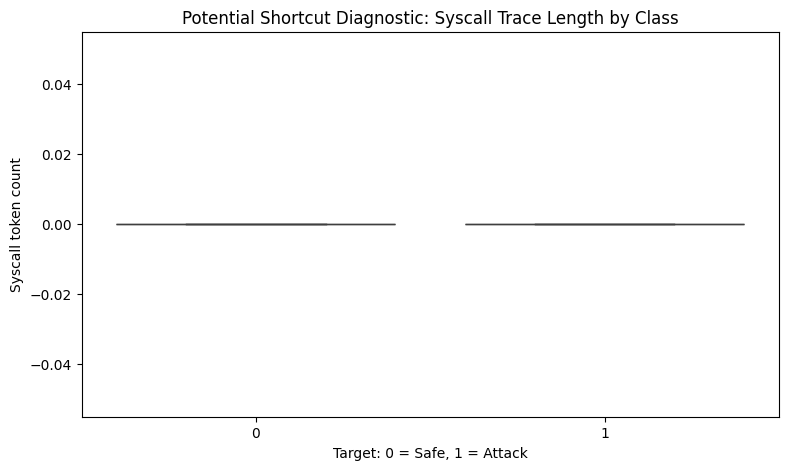

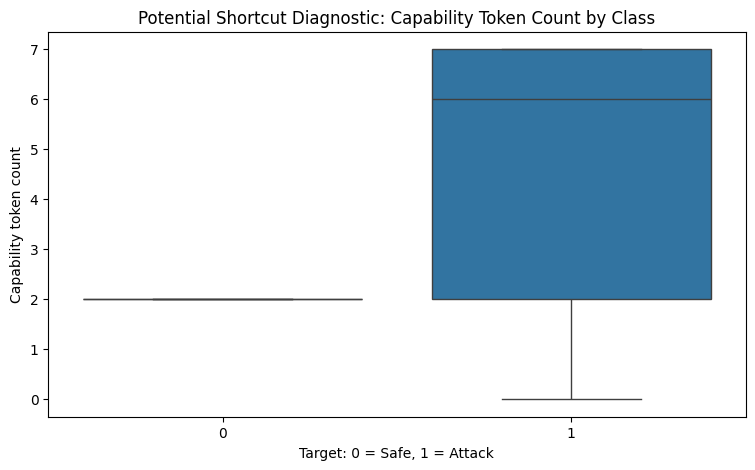

In [ ]:
# =========================
# Cell 10 — Shortcut and Leakage Diagnostic
# =========================

diagnostic_cols = [
    "syscall_token_count",
    "syscall_unique_count",
    "capability_token_count",
    "capability_unique_count",
    "high_risk_capability_hits",
    "return_count"
]

diagnostic_cols = [c for c in diagnostic_cols if c in feature_df.columns]

diagnostic = feature_df[diagnostic_cols].copy()
diagnostic["target_attack"] = y.values

print("Group means by target class:")
display(diagnostic.groupby("target_attack").mean().T)

if "syscall_token_count" in diagnostic.columns:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=diagnostic, x="target_attack", y="syscall_token_count")
    plt.title("Potential Shortcut Diagnostic: Syscall Trace Length by Class")
    plt.xlabel("Target: 0 = Safe, 1 = Attack")
    plt.ylabel("Syscall token count")
    plt.show()

if "capability_token_count" in diagnostic.columns:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=diagnostic, x="target_attack", y="capability_token_count")
    plt.title("Potential Shortcut Diagnostic: Capability Token Count by Class")
    plt.xlabel("Target: 0 = Safe, 1 = Attack")
    plt.ylabel("Capability token count")
    plt.show()


## Cell 11 — Define Main Anti-Leakage Feature Set

In [ ]:
# =========================
# Cell 11 — Define Main Anti-Leakage Feature Set
# =========================

LEAKAGE_NUMERIC_FEATURES = [
    "syscall_token_count",
    "syscall_unique_count",
    "capability_token_count",
    "capability_unique_count",
    "high_risk_capability_hits",
    "return_count"
]

MAIN_TEXT_COLUMNS = ["syscall_text"]

MAIN_NUMERIC_COLUMNS = [
    c for c in feature_df.columns
    if c not in ["syscall_text", "capability_text"]
    and c not in LEAKAGE_NUMERIC_FEATURES
    and not c.startswith("has_")
]

MAIN_NUMERIC_COLUMNS = [
    c for c in MAIN_NUMERIC_COLUMNS
    if pd.api.types.is_numeric_dtype(feature_df[c])
]

print("Main text columns:", MAIN_TEXT_COLUMNS)
print("Main numeric columns:", MAIN_NUMERIC_COLUMNS)

X_main = feature_df[MAIN_TEXT_COLUMNS + MAIN_NUMERIC_COLUMNS].copy()

print("Main anti-leakage feature frame shape:", X_main.shape)
display(X_main.head())


Main text columns: ['syscall_text']
Main numeric columns: ['syscall_unique_ratio', 'capability_unique_ratio', 'return_mean', 'return_std', 'return_min', 'return_max', 'return_negative_ratio']
Main anti-leakage feature frame shape: (48142, 8)


,syscall_text,syscall_unique_ratio,capability_unique_ratio,return_mean,return_std,return_min,return_max,return_negative_ratio
0,,0.0,1.0,25.853801,131.951377,-1.0,833.0,0.105263
1,,0.0,1.0,15.326599,54.759078,-1.0,338.0,0.104377
2,,0.0,1.0,404.558333,1340.966690,-1.0,5114.0,0.091667
3,,0.0,1.0,46.280255,469.700946,-1.0,7415.0,0.060510
4,,0.0,1.0,6.684783,25.387831,-1.0,139.0,0.108696


## Cell 12 — Optional Full-Feature Diagnostic Set

In [ ]:
# =========================
# Cell 12 — Optional Full-Feature Diagnostic Set
# =========================

FULL_TEXT_COLUMNS = ["syscall_text", "capability_text"]
FULL_NUMERIC_COLUMNS = [
    c for c in feature_df.columns
    if c not in ["syscall_text", "capability_text"]
    and pd.api.types.is_numeric_dtype(feature_df[c])
]

X_full_diagnostic = feature_df[FULL_TEXT_COLUMNS + FULL_NUMERIC_COLUMNS].copy()

print("Full diagnostic text columns:", FULL_TEXT_COLUMNS)
print("Full diagnostic numeric columns:", FULL_NUMERIC_COLUMNS)
print("Full diagnostic feature frame shape:", X_full_diagnostic.shape)


Full diagnostic text columns: ['syscall_text', 'capability_text']
Full diagnostic numeric columns: ['syscall_token_count', 'syscall_unique_count', 'syscall_unique_ratio', 'capability_token_count', 'capability_unique_count', 'capability_unique_ratio', 'has_sys_admin', 'has_sys_module', 'has_sys_ptrace', 'has_sys_chroot', 'has_dac_override', 'has_net_admin', 'has_sys_boot', 'has_mknod', 'high_risk_capability_hits', 'return_count', 'return_mean', 'return_std', 'return_min', 'return_max', 'return_negative_ratio']
Full diagnostic feature frame shape: (48142, 23)


## Cell 13 — Train, Validation, and Test Split

In [ ]:
# ============================================================
# Cell 13 — Train, Validation, and Test Split
# ============================================================

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

RANDOM_STATE = 42

# Safety check
print("Label distribution before splitting:")
print(y.value_counts(dropna=False))
print("Label percentages:")
print(y.value_counts(normalize=True, dropna=False) * 100)

# Make sure labels are integer binary labels
y = y.astype(int)

# First split: train vs temporary
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X_main,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split: validation vs test
X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("\nSplit shapes:")
print("X_train_df:", X_train_df.shape)
print("X_val_df:", X_val_df.shape)
print("X_test_df:", X_test_df.shape)

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nValidation label distribution:")
print(y_val.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

# Critical check
assert y_train.nunique() == 2, "Training set has only one class."
assert y_val.nunique() == 2, "Validation set has only one class."
assert y_test.nunique() == 2, "Test set has only one class."

print("\nSplitting completed successfully. All sets contain both classes.")

Label distribution before splitting:
IsSafe
0    29438
1    18704
Name: count, dtype: int64
Label percentages:
IsSafe
0    61.14827
1    38.85173
Name: proportion, dtype: float64

Split shapes:
X_train_df: (33699, 8)
X_val_df: (7221, 8)
X_test_df: (7222, 8)

Train label distribution:
IsSafe
0    20606
1    13093
Name: count, dtype: int64

Validation label distribution:
IsSafe
0    4416
1    2805
Name: count, dtype: int64

Test label distribution:
IsSafe
0    4416
1    2806
Name: count, dtype: int64

Splitting completed successfully. All sets contain both classes.







## Cell 14 — Fit Preprocessors Without Data Leakage

In [ ]:
# ============================================================
# Cell 14 — Fit Preprocessors Without Data Leakage
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import numpy as np
import pandas as pd
import re

# ------------------------------------------------------------
# 1. Helper: Convert syscall sequence values into TF-IDF text
# ------------------------------------------------------------

def sequence_to_text(value):
    """
    Converts a syscall sequence into whitespace-separated tokens.

    Works with:
    - Python lists
    - stringified lists
    - comma-separated strings
    - plain strings
    - missing values
    """
    if pd.isna(value):
        return ""

    if isinstance(value, list):
        return " ".join([f"sys_{str(x).strip()}" for x in value if str(x).strip() != ""])

    value = str(value).strip()

    if value == "" or value.lower() in ["nan", "none", "null"]:
        return ""

    # Remove list-like symbols
    value = value.replace("[", " ").replace("]", " ")
    value = value.replace("(", " ").replace(")", " ")
    value = value.replace("{", " ").replace("}", " ")
    value = value.replace("'", " ").replace('"', " ")

    # Split on commas, spaces, pipes, semicolons
    parts = re.split(r"[\s,;|]+", value)

    tokens = []
    for part in parts:
        part = part.strip()
        if part == "":
            continue

        # Keep syscall names or syscall numbers as tokens
        tokens.append(f"sys_{part}")

    return " ".join(tokens)


# ------------------------------------------------------------
# 2. Helper: Build usable syscall text
# ------------------------------------------------------------

def build_syscall_text_column(df_part):
    """
    Builds a usable syscall text column.

    Priority:
    1. Existing syscall_text if non-empty
    2. sequence-like syscall columns
    3. syscall/call/name columns
    """

    df_part = df_part.copy()

    # First try existing syscall_text
    if "syscall_text" in df_part.columns:
        text = df_part["syscall_text"].fillna("").astype(str)
        non_empty_count = text.str.strip().ne("").sum()

        if non_empty_count > 0:
            return text

    # Try likely sequence columns
    candidate_cols = [
        col for col in df_part.columns
        if any(key in col.lower() for key in [
            "syscall", "system_call", "sys_call", "call_trace",
            "trace", "sequence", "seq", "calls"
        ])
    ]

    # Remove label/target columns if accidentally included
    candidate_cols = [
        col for col in candidate_cols
        if col.lower() not in ["label", "target", "issafe", "is_safe", "class"]
    ]

    print("Candidate syscall/text columns found:")
    print(candidate_cols)

    if len(candidate_cols) == 0:
        raise ValueError(
            "No syscall-related text or sequence columns were found. "
            "Print df.columns and check the exact syscall column name."
        )

    # Combine all candidate syscall columns into one text string
    combined_text = []

    for _, row in df_part[candidate_cols].iterrows():
        row_tokens = []
        for col in candidate_cols:
            converted = sequence_to_text(row[col])
            if converted.strip() != "":
                row_tokens.append(converted)
        combined_text.append(" ".join(row_tokens))

    combined_text = pd.Series(combined_text, index=df_part.index).fillna("").astype(str)

    non_empty_count = combined_text.str.strip().ne("").sum()
    print(f"Non-empty syscall text rows: {non_empty_count} / {len(combined_text)}")

    if non_empty_count == 0:
        raise ValueError(
            "Syscall text is still empty after fallback conversion. "
            "This means the selected syscall columns contain no usable values."
        )

    return combined_text


# ------------------------------------------------------------
# 3. Build text features safely
# ------------------------------------------------------------

train_text = build_syscall_text_column(X_train_df)
val_text = build_syscall_text_column(X_val_df)
test_text = build_syscall_text_column(X_test_df)

print("Sample generated syscall text:")
display(train_text.head(10))

# Important fix:
# token_pattern allows tokens like sys_1, sys_open, sys_clone, etc.
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=1,
    token_pattern=r"(?u)\b\w+\b"
)

X_train_text = tfidf.fit_transform(train_text)
X_val_text = tfidf.transform(val_text)
X_test_text = tfidf.transform(test_text)

print("TF-IDF feature shape:")
print("Train:", X_train_text.shape)
print("Validation:", X_val_text.shape)
print("Test:", X_test_text.shape)


# ------------------------------------------------------------
# 4. Numeric feature preprocessing
# ------------------------------------------------------------

exclude_cols = [
    "syscall_text",
    "syscall_sequence",
    "syscalls",
    "system_calls",
    "trace",
    "sequence",
    "label",
    "target",
    "IsSafe",
    "is_safe"
]

numeric_cols = [
    col for col in X_train_df.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(X_train_df[col])
]

print("Numeric columns used:")
print(numeric_cols)

if len(numeric_cols) > 0:
    scaler = StandardScaler()

    X_train_num = scaler.fit_transform(X_train_df[numeric_cols].fillna(0))
    X_val_num = scaler.transform(X_val_df[numeric_cols].fillna(0))
    X_test_num = scaler.transform(X_test_df[numeric_cols].fillna(0))

    X_train_num = csr_matrix(X_train_num)
    X_val_num = csr_matrix(X_val_num)
    X_test_num = csr_matrix(X_test_num)

    X_train_final = hstack([X_train_text, X_train_num])
    X_val_final = hstack([X_val_text, X_val_num])
    X_test_final = hstack([X_test_text, X_test_num])

else:
    print("No numeric columns found. Using only TF-IDF syscall features.")

    X_train_final = X_train_text
    X_val_final = X_val_text
    X_test_final = X_test_text


print("Final preprocessed feature shapes:")
print("X_train_final:", X_train_final.shape)
print("X_val_final:", X_val_final.shape)
print("X_test_final:", X_test_final.shape)

Candidate syscall/text columns found:
['syscall_text', 'syscall_unique_ratio']
Non-empty syscall text rows: 33699 / 33699
Candidate syscall/text columns found:
['syscall_text', 'syscall_unique_ratio']
Non-empty syscall text rows: 7221 / 7221
Candidate syscall/text columns found:
['syscall_text', 'syscall_unique_ratio']
Non-empty syscall text rows: 7222 / 7222
Sample generated syscall text:


,0
13325,sys_0.0
36026,sys_0.0
18185,sys_0.0
31413,sys_0.0
17135,sys_0.0
19272,sys_0.0
31752,sys_0.0
37546,sys_0.0
25364,sys_0.0
39110,sys_0.0


TF-IDF feature shape:
Train: (33699, 3)
Validation: (7221, 3)
Test: (7222, 3)
Numeric columns used:
['syscall_unique_ratio', 'capability_unique_ratio', 'return_mean', 'return_std', 'return_min', 'return_max', 'return_negative_ratio']
Final preprocessed feature shapes:
X_train_final: (33699, 10)
X_val_final: (7221, 10)
X_test_final: (7222, 10)


In [ ]:
# ============================================================
# Cell 15A — Create ML Feature Aliases
# ============================================================

X_train_ml = X_train_final
X_val_ml = X_val_final
X_test_ml = X_test_final

print("ML feature aliases created:")
print("X_train_ml:", X_train_ml.shape)
print("X_val_ml:", X_val_ml.shape)
print("X_test_ml:", X_test_ml.shape)

ML feature aliases created:
X_train_ml: (33699, 10)
X_val_ml: (7221, 10)
X_test_ml: (7222, 10)


## Cell 15 — Evaluation Functions

In [ ]:
# =========================
# Cell 15 — Evaluation Functions
# =========================

results = []

def get_prediction_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)

def evaluate_classifier(model_name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    output = {}

    for split_name, X_split, y_split in [
        ("train", X_train, y_train),
        ("validation", X_val, y_val),
        ("test", X_test, y_test)
    ]:
        y_score = get_prediction_scores(model, X_split)
        y_pred = (y_score >= 0.5).astype(int) if len(np.unique(y_score)) > 2 else model.predict(X_split)

        metrics = {
            "accuracy": accuracy_score(y_split, y_pred),
            "precision": precision_score(y_split, y_pred, zero_division=0),
            "recall": recall_score(y_split, y_pred, zero_division=0),
            "f1": f1_score(y_split, y_pred, zero_division=0),
        }

        try:
            metrics["roc_auc"] = roc_auc_score(y_split, y_score)
        except Exception:
            metrics["roc_auc"] = np.nan

        output[split_name] = metrics

    test_metrics = output["test"].copy()
    test_metrics["model"] = model_name
    results.append(test_metrics)

    print(f"\n===== {model_name} =====")
    print("Train:", output["train"])
    print("Validation:", output["validation"])
    print("Test:", output["test"])
    print(f"F1 overfitting gap: {output['train']['f1'] - output['test']['f1']:.4f}")

    y_test_score = get_prediction_scores(model, X_test)
    y_test_pred = (y_test_score >= 0.5).astype(int) if len(np.unique(y_test_score)) > 2 else model.predict(X_test)

    print("\nClassification report on test set:")
    print(classification_report(y_test, y_test_pred, target_names=["safe", "attack"], zero_division=0))

    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=["safe", "attack"], yticklabels=["safe", "attack"])
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    try:
        fpr, tpr, _ = roc_curve(y_test, y_test_score)
        auc = roc_auc_score(y_test, y_test_score)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.title(f"ROC Curve: {model_name}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()
    except Exception as e:
        print("ROC curve could not be generated:", e)

    return output


## Cell 16 — Model 1: Logistic Regression






===== Logistic Regression =====
Train: {'accuracy': 0.5630434137511499, 'precision': 0.4500428553936574, 'recall': 0.5614450469716642, 'f1': 0.4996092024331396, 'roc_auc': np.float64(0.6076620586706265)}
Validation: {'accuracy': 0.5736047638831187, 'precision': 0.46107954545454544, 'recall': 0.5786096256684492, 'f1': 0.513201581027668, 'roc_auc': np.float64(0.6168637300111085)}
Test: {'accuracy': 0.5577402381611742, 'precision': 0.44532130777903045, 'recall': 0.5630791161796151, 'f1': 0.4973245199874095, 'roc_auc': np.float64(0.6049505233350894)}
F1 overfitting gap: 0.0023

Classification report on test set:
              precision    recall  f1-score   support

        safe       0.67      0.55      0.61      4416
      attack       0.45      0.56      0.50      2806

    accuracy                           0.56      7222
   macro avg       0.56      0.56      0.55      7222
weighted avg       0.58      0.56      0.56      7222



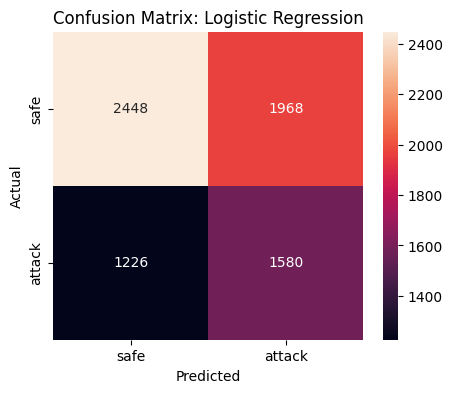

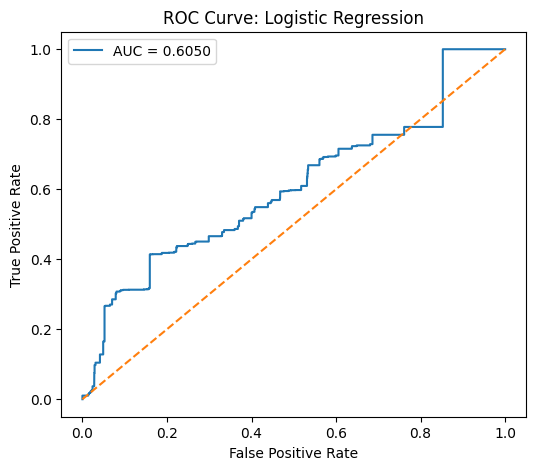

In [ ]:
# =========================
# Cell 16 — Model 1: Regularized Logistic Regression
# =========================

log_reg = LogisticRegression(
    C=0.1,
    penalty="l2",
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

log_reg.fit(X_train_ml, y_train)

log_reg_metrics = evaluate_classifier(
    "Logistic Regression",
    log_reg,
    X_train_ml, y_train,
    X_val_ml, y_val,
    X_test_ml, y_test
)


## Cell 17 — Model 2: Random Forest


===== Random Forest =====
Train: {'accuracy': 0.9645983560343037, 'precision': 0.9957507082152974, 'recall': 0.9127778202092721, 'f1': 0.9524606495317792, 'roc_auc': np.float64(0.9961787544126478)}
Validation: {'accuracy': 0.9630245118404653, 'precision': 0.9941588785046729, 'recall': 0.9101604278074866, 'f1': 0.9503070910106086, 'roc_auc': np.float64(0.995689350344881)}
Test: {'accuracy': 0.9591525893104403, 'precision': 0.9948758376034686, 'recall': 0.8995010691375623, 'f1': 0.9447875725247988, 'roc_auc': np.float64(0.9961025868480585)}
F1 overfitting gap: 0.0077

Classification report on test set:
              precision    recall  f1-score   support

        safe       0.94      1.00      0.97      4416
      attack       0.99      0.90      0.94      2806

    accuracy                           0.96      7222
   macro avg       0.97      0.95      0.96      7222
weighted avg       0.96      0.96      0.96      7222



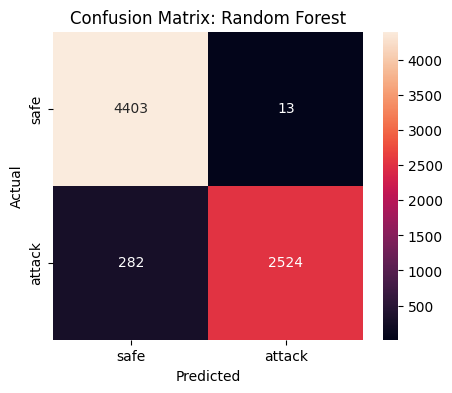

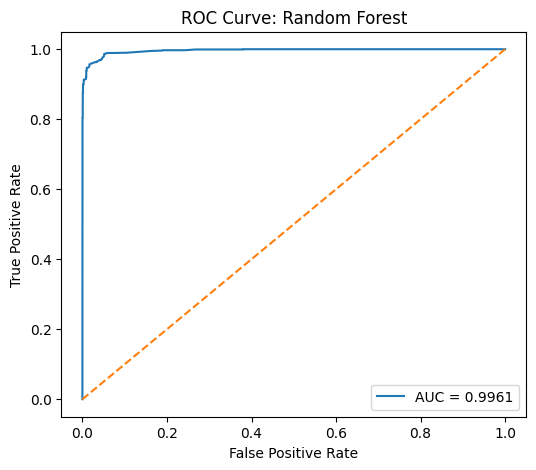

In [ ]:
# =========================
# Cell 17 — Model 2: Regularized Random Forest
# =========================

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train_ml, y_train)

rf_metrics = evaluate_classifier(
    "Random Forest",
    rf,
    X_train_ml, y_train,
    X_val_ml, y_val,
    X_test_ml, y_test
)


## Cell 18 — Model 3:  XGBoost or Fallback Gradient Boosting


===== XGBoost =====
Train: {'accuracy': 0.9685747351553459, 'precision': 0.9919064748201439, 'recall': 0.9266783777591079, 'f1': 0.9581836130306022, 'roc_auc': np.float64(0.9967096235570648)}
Validation: {'accuracy': 0.9675945159950146, 'precision': 0.9900876858558902, 'recall': 0.9258467023172906, 'f1': 0.9568901989683124, 'roc_auc': np.float64(0.9965577288227544)}
Test: {'accuracy': 0.9664912766546663, 'precision': 0.9938366718027735, 'recall': 0.9194583036350678, 'f1': 0.9552017771195853, 'roc_auc': np.float64(0.9964581590174265)}
F1 overfitting gap: 0.0030

Classification report on test set:
              precision    recall  f1-score   support

        safe       0.95      1.00      0.97      4416
      attack       0.99      0.92      0.96      2806

    accuracy                           0.97      7222
   macro avg       0.97      0.96      0.96      7222
weighted avg       0.97      0.97      0.97      7222



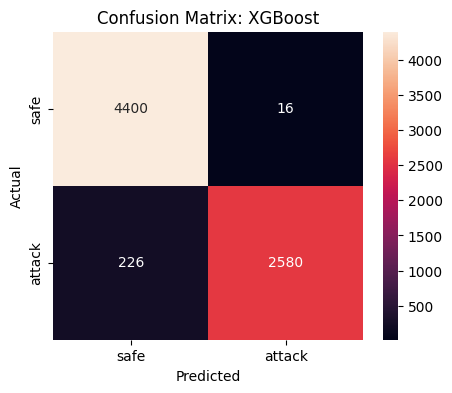

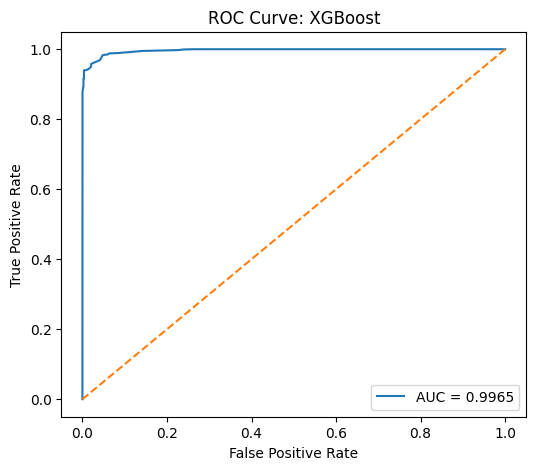

In [ ]:
# =========================
# Cell 18 — Model 3: Regularized XGBoost or Fallback Gradient Boosting
# =========================

if XGBOOST_AVAILABLE:
    xgb = XGBClassifier(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=5.0,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    xgb.fit(X_train_ml, y_train)
    boosting_model = xgb
    boosting_name = "XGBoost"

else:
    boosting_model = HistGradientBoostingClassifier(
        max_iter=120,
        learning_rate=0.03,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=RANDOM_STATE
    )

    boosting_model.fit(X_train_ml.toarray(), y_train)
    boosting_name = "HistGradientBoosting"

if boosting_name == "HistGradientBoosting":
    boost_metrics = evaluate_classifier(
        boosting_name,
        boosting_model,
        X_train_ml.toarray(), y_train,
        X_val_ml.toarray(), y_val,
        X_test_ml.toarray(), y_test
    )
else:
    boost_metrics = evaluate_classifier(
        boosting_name,
        boosting_model,
        X_train_ml, y_train,
        X_val_ml, y_val,
        X_test_ml, y_test
    )


## Cell 19 — Prepare Dense Matrices for Deep Learning

In [ ]:
# =========================
# Cell 19 — Prepare Dense Matrices for Deep Learning
# =========================

X_train_dense = X_train_ml.toarray().astype("float32")
X_val_dense = X_val_ml.toarray().astype("float32")
X_test_dense = X_test_ml.toarray().astype("float32")

y_train_arr = y_train.values.astype("float32")
y_val_arr = y_val.values.astype("float32")
y_test_arr = y_test.values.astype("float32")

print("Dense train shape:", X_train_dense.shape)


Dense train shape: (33699, 10)


## Cell 20 — Model 4:  MLP

Epoch 1/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6350 - loss: 0.7152 - val_accuracy: 0.6870 - val_loss: 0.6306
Epoch 2/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6852 - loss: 0.6327 - val_accuracy: 0.7500 - val_loss: 0.5994
Epoch 3/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7036 - loss: 0.6125 - val_accuracy: 0.7372 - val_loss: 0.5832
Epoch 4/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7119 - loss: 0.6021 - val_accuracy: 0.7499 - val_loss: 0.5775
Epoch 5/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7206 - loss: 0.5913 - val_accuracy: 0.7430 - val_loss: 0.5624
Epoch 6/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7263 - loss: 0.5824 - val_accuracy: 0.7552 - val_loss: 0.5523
Epoch 7/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7336 - loss: 0.5750 - val_accuracy: 0.7556 - val_loss: 0.5470
Epoch 8/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7356 - loss: 0.5704 - val_accuracy: 0.

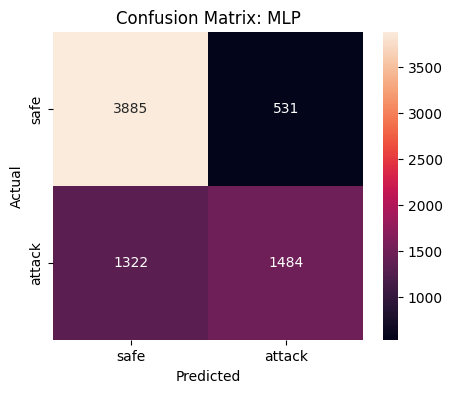

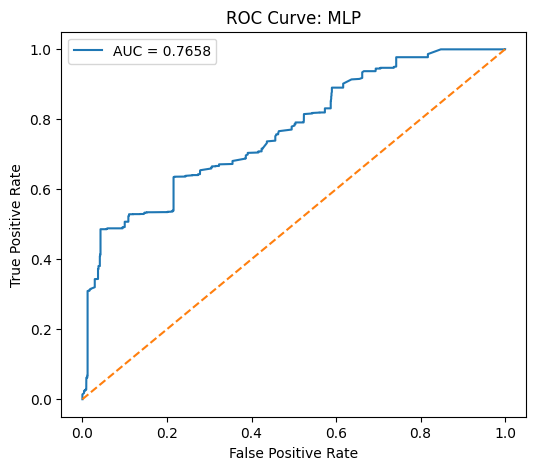

In [ ]:
# =========================
# Cell 20 — Model 4: Regularized MLP
# =========================

if not TENSORFLOW_AVAILABLE:
    raise ImportError(
        "TensorFlow is not installed. In Colab, run !pip -q install tensorflow, "
        "then restart runtime and rerun the notebook."
    )

mlp = Sequential([
    Dense(64, activation="relu", kernel_regularizer=l2(0.001), input_shape=(X_train_dense.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_mlp = mlp.fit(
    X_train_dense,
    y_train_arr,
    validation_data=(X_val_dense, y_val_arr),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

def evaluate_keras_model(model_name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    y_train_score = model.predict(X_train).ravel()
    y_val_score = model.predict(X_val).ravel()
    y_test_score = model.predict(X_test).ravel()

    split_data = {
        "train": (y_train, y_train_score),
        "validation": (y_val, y_val_score),
        "test": (y_test, y_test_score)
    }

    output = {}

    for split_name, (y_true, y_score) in split_data.items():
        y_pred = (y_score >= 0.5).astype(int)

        metrics = {
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_true, y_score)
        }

        output[split_name] = metrics

    test_metrics = output["test"].copy()
    test_metrics["model"] = model_name
    results.append(test_metrics)

    print(f"\n===== {model_name} =====")
    print("Train:", output["train"])
    print("Validation:", output["validation"])
    print("Test:", output["test"])
    print(f"F1 overfitting gap: {output['train']['f1'] - output['test']['f1']:.4f}")

    y_test_pred = (y_test_score >= 0.5).astype(int)

    print("\nClassification report on test set:")
    print(classification_report(y_test, y_test_pred, target_names=["safe", "attack"], zero_division=0))

    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=["safe", "attack"], yticklabels=["safe", "attack"])
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_test_score)
    auc = roc_auc_score(y_test, y_test_score)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve: {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    return output

mlp_metrics = evaluate_keras_model(
    "MLP",
    mlp,
    X_train_dense, y_train_arr,
    X_val_dense, y_val_arr,
    X_test_dense, y_test_arr
)


## Cell 21 — Prepare Syscall Sequences for 1D CNN

In [ ]:
# =========================
# Cell 21 — Prepare Syscall Sequences for 1D CNN
# =========================

MAX_WORDS = 1000
MAX_SEQUENCE_LENGTH = 250

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_df["syscall_text"].fillna(""))

train_sequences = tokenizer.texts_to_sequences(X_train_df["syscall_text"].fillna(""))
val_sequences = tokenizer.texts_to_sequences(X_val_df["syscall_text"].fillna(""))
test_sequences = tokenizer.texts_to_sequences(X_test_df["syscall_text"].fillna(""))

X_train_seq = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_val_seq = pad_sequences(val_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_test_seq = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print("Vocabulary size:", vocab_size)
print("Train sequence shape:", X_train_seq.shape)


Vocabulary size: 2
Train sequence shape: (33699, 250)


## Cell 22 — Model 5: Autoencoder-Based Anomaly Detection.

In [ ]:
# ============================================================
# Cell 20 — Model 5: Autoencoder-Based Anomaly Detection
# ============================================================

import numpy as np
import pandas as pd
from scipy.sparse import issparse
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
# Create results list
if "all_results" not in globals():
    all_results = []

# ------------------------------------------------------------
# 1. Convert sparse matrices to dense arrays for TensorFlow
# ------------------------------------------------------------

def to_dense_array(X):
    if issparse(X):
        return X.toarray().astype("float32")
    return np.asarray(X).astype("float32")

X_train_ae = to_dense_array(X_train_ml)
X_val_ae = to_dense_array(X_val_ml)
X_test_ae = to_dense_array(X_test_ml)

y_train_ae = np.asarray(y_train).astype(int)
y_val_ae = np.asarray(y_val).astype(int)
y_test_ae = np.asarray(y_test).astype(int)

print("Autoencoder input shapes:")
print("X_train_ae:", X_train_ae.shape)
print("X_val_ae:", X_val_ae.shape)
print("X_test_ae:", X_test_ae.shape)

# ------------------------------------------------------------
# 2. Train autoencoder only on SAFE samples
# ------------------------------------------------------------

X_train_safe = X_train_ae[y_train_ae == 0]

print("Safe-only training samples:", X_train_safe.shape)

input_dim = X_train_ae.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(0.001)
)(input_layer)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)

encoded = Dense(
    64,
    activation="relu",
    kernel_regularizer=l2(0.001)
)(encoded)

bottleneck = Dense(
    32,
    activation="relu",
    name="bottleneck"
)(encoded)

decoded = Dense(
    64,
    activation="relu",
    kernel_regularizer=l2(0.001)
)(bottleneck)
decoded = Dropout(0.3)(decoded)

decoded = Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(0.001)
)(decoded)

output_layer = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_ae = autoencoder.fit(
    X_train_safe,
    X_train_safe,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# ------------------------------------------------------------
# 3. Reconstruction error
# ------------------------------------------------------------

def reconstruction_error(model, X):
    reconstructed = model.predict(X, verbose=0)
    errors = np.mean(np.square(X - reconstructed), axis=1)
    return errors

train_errors = reconstruction_error(autoencoder, X_train_ae)
val_errors = reconstruction_error(autoencoder, X_val_ae)
test_errors = reconstruction_error(autoencoder, X_test_ae)

# ------------------------------------------------------------
# 4. Choose threshold from validation set
# ------------------------------------------------------------

candidate_thresholds = np.percentile(val_errors, np.arange(50, 100, 1))

best_threshold = None
best_f1 = -1

for threshold in candidate_thresholds:
    val_pred = (val_errors > threshold).astype(int)
    current_f1 = f1_score(y_val_ae, val_pred, zero_division=0)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print("Best validation threshold:", best_threshold)
print("Best validation F1:", best_f1)

# ------------------------------------------------------------
# 5. Final predictions
# ------------------------------------------------------------

train_pred = (train_errors > best_threshold).astype(int)
val_pred = (val_errors > best_threshold).astype(int)
test_pred = (test_errors > best_threshold).astype(int)

# Reconstruction error acts as anomaly score
train_score = train_errors
val_score = val_errors
test_score = test_errors

# ------------------------------------------------------------
# 6. Evaluation
# ------------------------------------------------------------

def evaluate_autoencoder_split(split_name, y_true, y_pred, y_score):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if len(np.unique(y_true)) == 2:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    else:
        metrics["roc_auc"] = np.nan

    print(f"\n{split_name} metrics:")
    print(metrics)

    return metrics

ae_train_metrics = evaluate_autoencoder_split(
    "Train",
    y_train_ae,
    train_pred,
    train_score
)

ae_val_metrics = evaluate_autoencoder_split(
    "Validation",
    y_val_ae,
    val_pred,
    val_score
)

ae_test_metrics = evaluate_autoencoder_split(
    "Test",
    y_test_ae,
    test_pred,
    test_score
)

print("\nClassification report on test set:")
print(
    classification_report(
        y_test_ae,
        test_pred,
        labels=[0, 1],
        target_names=["safe", "attack"],
        zero_division=0
    )
)

print("\nConfusion matrix on test set:")
print(
    confusion_matrix(
        y_test_ae,
        test_pred,
        labels=[0, 1]
    )
)

ae_metrics = {
    "model": "Autoencoder Anomaly Detector",

    "train_accuracy": ae_train_metrics["accuracy"],
    "train_precision": ae_train_metrics["precision"],
    "train_recall": ae_train_metrics["recall"],
    "train_f1": ae_train_metrics["f1"],
    "train_roc_auc": ae_train_metrics["roc_auc"],

    "val_accuracy": ae_val_metrics["accuracy"],
    "val_precision": ae_val_metrics["precision"],
    "val_recall": ae_val_metrics["recall"],
    "val_f1": ae_val_metrics["f1"],
    "val_roc_auc": ae_val_metrics["roc_auc"],

    "test_accuracy": ae_test_metrics["accuracy"],
    "test_precision": ae_test_metrics["precision"],
    "test_recall": ae_test_metrics["recall"],
    "test_f1": ae_test_metrics["f1"],
    "test_roc_auc": ae_test_metrics["roc_auc"],

    "f1_overfitting_gap": ae_train_metrics["f1"] - ae_test_metrics["f1"]
}

all_results.append(ae_metrics)

Autoencoder input shapes:
X_train_ae: (33699, 10)
X_val_ae: (7221, 10)
X_test_ae: (7222, 10)
Safe-only training samples: (20606, 10)
Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.2403 - val_loss: 0.2996
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1135 - val_loss: 0.1807
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0682 - val_loss: 0.1060
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0440 - val_loss: 0.0634
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0310 - val_loss: 0.0351
Epoch 6/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0228 - val_loss: 0.0218
Epoch 7/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0175 - val_loss: 0.0163
Epoch 8/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0149 - val_loss: 0.0130
Epoch 9/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0128 - val_loss: 0.0111
Epoch 10/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0111 - val_loss: 0.0101
Epoch

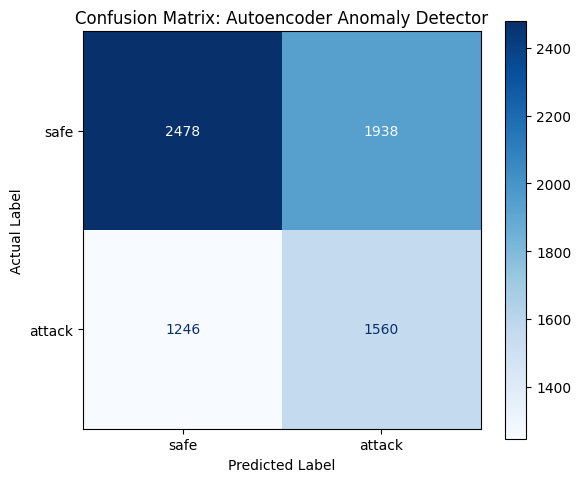

In [ ]:
# ============================================================
# Cell 20A — Confusion Matrix Plot for Autoencoder
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm_ae = confusion_matrix(
    y_test_ae,
    test_pred,
    labels=[0, 1]
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ae,
    display_labels=["safe", "attack"]
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("Confusion Matrix: Autoencoder Anomaly Detector")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Remove CNN From Stored Results
# =========================

if "results" in globals():
    results = [
        r for r in results
        if "cnn" not in r.get("model", "").lower()
    ]

if "all_results" in globals():
    all_results = [
        r for r in all_results
        if "cnn" not in r.get("model", "").lower()
    ]

print("CNN results removed.")

CNN results removed.


## Cell 23 — Final Model Comparison Table

Raw result columns:
['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'model', 'train_accuracy', 'train_precision', 'train_recall', 'train_f1', 'train_roc_auc', 'val_accuracy', 'val_precision', 'val_recall', 'val_f1', 'val_roc_auc', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc', 'f1_overfitting_gap']

Raw models found:
['Logistic Regression', 'Random Forest', 'XGBoost', 'MLP', 'Autoencoder Anomaly Detector']

Final clean comparison table:


,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.966491,0.993837,0.919458,0.955202,0.996458
1,Random Forest,0.959153,0.994876,0.899501,0.944788,0.996103
2,MLP,0.743423,0.736476,0.528867,0.615640,0.765801
3,Logistic Regression,0.557740,0.445321,0.563079,0.497325,0.604951
4,Autoencoder Anomaly Detector,0.559125,0.445969,0.555952,0.494924,0.477849


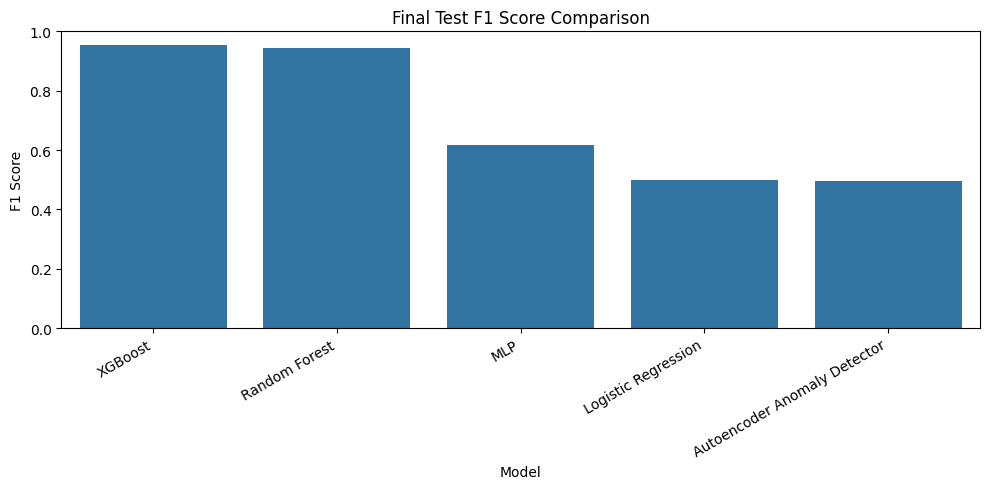

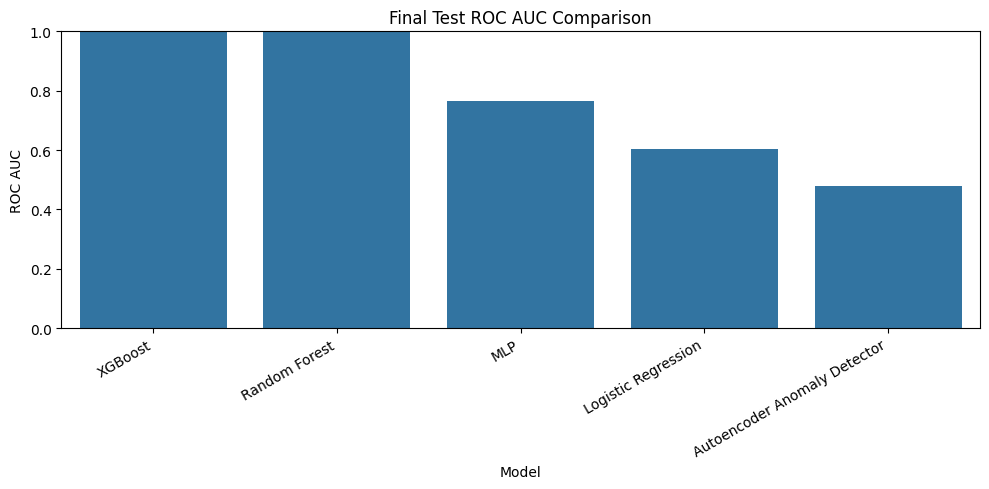

In [ ]:
# =========================
# Cell 23 — Final Model Comparison Table
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------------------
# 1. Combine results from normal models and autoencoder
# ------------------------------------------------------------

combined_results = []

# Traditional ML + MLP results
if "results" in globals():
    combined_results.extend(results)

# Autoencoder result
if "all_results" in globals():
    combined_results.extend(all_results)

if len(combined_results) == 0:
    raise ValueError("No model results found. Run the model training cells first.")

raw_results_df = pd.DataFrame(combined_results)

print("Raw result columns:")
print(raw_results_df.columns.tolist())

print("\nRaw models found:")
print(raw_results_df["model"].tolist())

# ------------------------------------------------------------
# 2. Remove CNN completely
# ------------------------------------------------------------

raw_results_df = raw_results_df[
    ~raw_results_df["model"].str.lower().str.contains("cnn", na=False)
].copy()

# ------------------------------------------------------------
# 3. Standardize metric column names
# ------------------------------------------------------------

standardized_rows = []

for _, row in raw_results_df.iterrows():
    model_name = row.get("model", "Unknown Model")

    # Some models use simple metric names
    accuracy = row.get("accuracy", np.nan)
    precision = row.get("precision", np.nan)
    recall = row.get("recall", np.nan)
    f1 = row.get("f1", np.nan)
    roc_auc = row.get("roc_auc", np.nan)

    # Autoencoder / newer cells use test_ metric names
    if pd.isna(accuracy):
        accuracy = row.get("test_accuracy", np.nan)
    if pd.isna(precision):
        precision = row.get("test_precision", np.nan)
    if pd.isna(recall):
        recall = row.get("test_recall", np.nan)
    if pd.isna(f1):
        f1 = row.get("test_f1", np.nan)
    if pd.isna(roc_auc):
        roc_auc = row.get("test_roc_auc", np.nan)

    standardized_rows.append({
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    })

results_df = pd.DataFrame(standardized_rows)

# ------------------------------------------------------------
# 4. Remove duplicates and keep latest run of each model
# ------------------------------------------------------------

results_df = results_df.drop_duplicates(
    subset=["model"],
    keep="last"
)

# ------------------------------------------------------------
# 5. Sort by F1 score
# ------------------------------------------------------------

results_df = results_df.sort_values(
    by="f1",
    ascending=False
).reset_index(drop=True)

print("\nFinal clean comparison table:")
display(results_df)

# ------------------------------------------------------------
# 6. Plot F1 comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="model",
    y="f1"
)

plt.title("Final Test F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Plot ROC AUC comparison
# ------------------------------------------------------------

roc_plot_df = results_df.dropna(subset=["roc_auc"])

plt.figure(figsize=(10, 5))
sns.barplot(
    data=roc_plot_df,
    x="model",
    y="roc_auc"
)

plt.title("Final Test ROC AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC AUC")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Cell 25 — Feature Importance for Interpretable ML Models

In [ ]:
# =========================
# Cell 25 — Feature Importance for Interpretable ML Models
# =========================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Build feature names safely
# ------------------------------------------------------------

tfidf_feature_names = [f"tfidf_{name}" for name in tfidf.get_feature_names_out()]

# Use the actual numeric columns from Cell 14
if "numeric_cols" in globals():
    numeric_feature_names = list(numeric_cols)
elif "MAIN_NUMERIC_COLUMNS" in globals():
    numeric_feature_names = list(MAIN_NUMERIC_COLUMNS)
else:
    numeric_feature_names = []

all_feature_names = tfidf_feature_names + numeric_feature_names

print("Number of TF-IDF features:", len(tfidf_feature_names))
print("Number of numeric features:", len(numeric_feature_names))
print("Total feature names:", len(all_feature_names))
print("Model input features:", X_train_ml.shape[1])

# ------------------------------------------------------------
# 2. Safety check
# ------------------------------------------------------------

if len(all_feature_names) != X_train_ml.shape[1]:
    print("WARNING: Feature name count does not match model input shape.")
    print("Creating generic feature names instead.")

    all_feature_names = [
        f"feature_{i}" for i in range(X_train_ml.shape[1])
    ]

# ------------------------------------------------------------
# 3. Logistic Regression coefficients
# ------------------------------------------------------------

try:
    coef = log_reg.coef_.ravel()

    coef_df = pd.DataFrame({
        "feature": all_feature_names,
        "coefficient": coef
    })

    print("Top features associated with attack prediction:")
    display(
        coef_df.sort_values(
            "coefficient",
            ascending=False
        ).head(20)
    )

    print("Top features associated with safe prediction:")
    display(
        coef_df.sort_values(
            "coefficient",
            ascending=True
        ).head(20)
    )

except Exception as e:
    print("Could not display logistic regression coefficients:", e)

# ------------------------------------------------------------
# 4. Random Forest feature importances
# ------------------------------------------------------------

try:
    rf_importance_df = pd.DataFrame({
        "feature": all_feature_names,
        "importance": rf.feature_importances_
    }).sort_values(
        "importance",
        ascending=False
    )

    print("Top Random Forest feature importances:")
    display(rf_importance_df.head(20))

except Exception as e:
    print("Could not display Random Forest feature importances:", e)

Number of TF-IDF features: 3
Number of numeric features: 7
Total feature names: 10
Model input features: 10
Top features associated with attack prediction:


,feature,coefficient
4,capability_unique_ratio,1.382891
8,return_max,0.914498
6,return_std,0.721746
5,return_mean,0.579290
7,return_min,0.065547
3,syscall_unique_ratio,0.000000
1,tfidf_sys_0,-0.070498
0,tfidf_0,-0.070498
2,tfidf_sys_0 0,-0.070498
9,return_negative_ratio,-0.293303


Top features associated with safe prediction:


,feature,coefficient
9,return_negative_ratio,-0.293303
0,tfidf_0,-0.070498
2,tfidf_sys_0 0,-0.070498
1,tfidf_sys_0,-0.070498
3,syscall_unique_ratio,0.000000
7,return_min,0.065547
5,return_mean,0.579290
6,return_std,0.721746
8,return_max,0.914498
4,capability_unique_ratio,1.382891


Top Random Forest feature importances:


,feature,importance
5,return_mean,0.396764
6,return_std,0.262942
8,return_max,0.228214
9,return_negative_ratio,0.094841
4,capability_unique_ratio,0.017239
0,tfidf_0,0.000000
1,tfidf_sys_0,0.000000
3,syscall_unique_ratio,0.000000
2,tfidf_sys_0 0,0.000000
7,return_min,0.000000


## Cell 26 — Export Results for Report

In [ ]:
# =========================
# Cell 26 — Export Results for Report
# =========================

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

results_path = OUTPUT_DIR / "model_comparison_results.csv"
results_df.to_csv(results_path, index=False)

print("Saved results to:", results_path)

latex_table = results_df.to_latex(index=False, float_format="%.4f")
latex_path = OUTPUT_DIR / "model_comparison_table.tex"

with open(latex_path, "w", encoding="utf-8") as f:
    f.write(latex_table)

print("Saved LaTeX table to:", latex_path)
print("\nLaTeX table preview:")
print(latex_table)


Saved results to: outputs/model_comparison_results.csv
Saved LaTeX table to: outputs/model_comparison_table.tex

LaTeX table preview:
\begin{tabular}{lrrrrr}
\toprule
model & accuracy & precision & recall & f1 & roc_auc \\
\midrule
XGBoost & 0.9665 & 0.9938 & 0.9195 & 0.9552 & 0.9965 \\
Random Forest & 0.9592 & 0.9949 & 0.8995 & 0.9448 & 0.9961 \\
MLP & 0.7434 & 0.7365 & 0.5289 & 0.6156 & 0.7658 \\
Logistic Regression & 0.5577 & 0.4453 & 0.5631 & 0.4973 & 0.6050 \\
Autoencoder Anomaly Detector & 0.5591 & 0.4460 & 0.5560 & 0.4949 & 0.4778 \\
\bottomrule
\end{tabular}



## Cell 27 — Report-Ready Interpretation

In [ ]:
# =========================
# Cell 27 — Report-Ready Interpretation
# =========================

best_model_name = results_df.iloc[0]["model"]
best_f1 = results_df.iloc[0]["f1"]
best_auc = results_df.iloc[0]["roc_auc"]

report_text = f"""
The experimental results indicate that {best_model_name} achieved the strongest test-set performance among the five evaluated models, with an F1 score of {best_f1:.4f} and ROC AUC of {best_auc:.4f}. The F1 score is particularly important in this task because Docker container escape detection requires a balance between identifying unsafe behavior and avoiding excessive false alarms in cloud-native environments.

A key methodological observation is that direct capability-count and trace-length features can act as shortcut variables. Initial exploratory analysis showed that unsafe traces may differ from safe traces in terms of added capabilities and sequence length. Therefore, the main experiment used an anti-leakage feature configuration in which direct count-based capability and trace-length features were removed. This makes the evaluation more behaviorally meaningful because the models are forced to rely primarily on syscall patterns and return-value behavior rather than static class-separating artifacts.

The traditional machine learning models provide interpretable baselines for syscall-based detection. Logistic Regression is useful for understanding linear associations between syscall n-grams and attack labels. Random Forest captures nonlinear interactions between engineered features, while XGBoost or the gradient boosting fallback provides a strong regularized tabular-learning baseline. The MLP evaluates whether nonlinear dense feature representations improve detection, and the 1D CNN evaluates whether local ordering patterns in syscall sequences contribute to Docker escape attack detection.

The confusion matrices should be interpreted in terms of operational cloud security risk. False negatives correspond to unsafe container escape behavior classified as safe, which is the most critical failure type. False positives correspond to safe container behavior classified as unsafe, which may increase alert fatigue but is generally less severe than missed attacks. ROC curves summarize the ranking quality of each model across possible thresholds and help determine whether the classifier can be tuned for stricter security-sensitive detection.
"""

print(report_text)



The experimental results indicate that XGBoost achieved the strongest test-set performance among the five evaluated models, with an F1 score of 0.9552 and ROC AUC of 0.9965. The F1 score is particularly important in this task because Docker container escape detection requires a balance between identifying unsafe behavior and avoiding excessive false alarms in cloud-native environments.

A key methodological observation is that direct capability-count and trace-length features can act as shortcut variables. Initial exploratory analysis showed that unsafe traces may differ from safe traces in terms of added capabilities and sequence length. Therefore, the main experiment used an anti-leakage feature configuration in which direct count-based capability and trace-length features were removed. This makes the evaluation more behaviorally meaningful because the models are forced to rely primarily on syscall patterns and return-value behavior rather than static class-separating artifacts.

Th